In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Fixer les seeds pour la reproductibilité
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
# 1) Chargement MNIST et vérification des dimensions
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print('Train images:', x_train.shape, '| Train labels:', y_train.shape)
print('Test  images:', x_test.shape,  '| Test  labels:', y_test.shape)
print('Pixel dtype:', x_train.dtype, '| Label dtype:', y_train.dtype)



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train images: (60000, 28, 28) | Train labels: (60000,)
Test  images: (10000, 28, 28) | Test  labels: (10000,)
Pixel dtype: uint8 | Label dtype: uint8


In [ ]:
# Split Train / Val (val = 1000 dernières images)

val_size = 10000
x_val = x_train[-val_size:]
y_val = y_train[-val_size:]

x_train_final = x_train[:-val_size]
y_train_final = y_train[:-val_size]

print("\nAprès split:")
print("Train :", x_train_final.shape, y_train_final.shape)
print("Val   :", x_val.shape, y_val.shape)
print("Test  :", x_test.shape, y_test.shape)


Après split:
Train : (50000, 28, 28) (50000,)
Val   : (10000, 28, 28) (10000,)
Test  : (10000, 28, 28) (10000,)


In [ ]:
# 2) Normalisation des pixels
x_train_final_norm = x_train_final.astype('float32') / 255.0
x_val_norm         = x_val.astype('float32')/ 255.0
x_test_norm        = x_test.astype('float32')/ 255.0

print('\nAprès normalisation:')
print('dtype:', x_train_final_norm.dtype)
print('min/max train:', x_train_final_norm.min(), x_train_final_norm.max())


Après normalisation:
dtype: float32
min/max train: 0.0 1.0


In [ ]:
# 3) Reshape (CNN attend 4D)
# print('\nAprès reshape pour CNN:')
# print('Train:', x_train_final_norm.shape)
# print('Val  :', x_val_norm.shape)
# print('Test :', x_test_norm.shape)
x_train_final_norm = np.expand_dims(x_train_final_norm, axis=-1)  # (50000, 28, 28, 1)
x_val_norm         = np.expand_dims(x_val_norm,         axis=-1)  # (10000, 28, 28, 1)
x_test_norm        = np.expand_dims(x_test_norm,        axis=-1)  # (10000, 28, 28, 1)

print('\nAprès reshape pour CNN:')
print('Train:', x_train_final_norm.shape)
print('Val  :', x_val_norm.shape)
print('Test :', x_test_norm.shape)


Après reshape pour CNN:
Train: (50000, 28, 28, 1)
Val  : (10000, 28, 28, 1)
Test : (10000, 28, 28, 1)



Batch récupéré (sans augmentation): (16, 28, 28, 1) (16,)


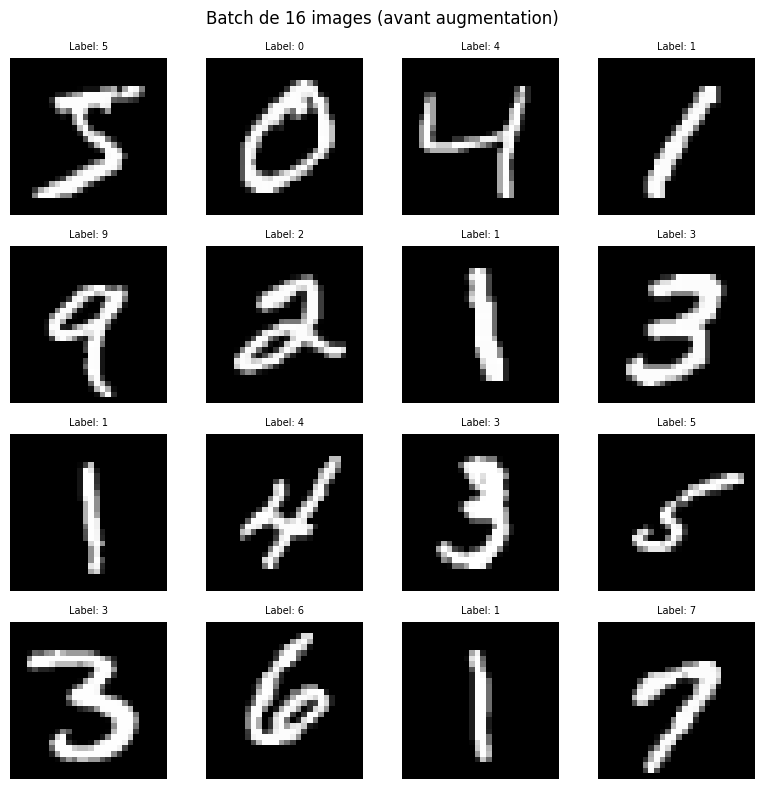

In [ ]:
batch_size = 16

# Générateur SANS augmentation
gen_no_aug = ImageDataGenerator()  # aucune transformation

# shuffle=False pour récupérer un batch stable (mêmes images)
flow_no_aug = gen_no_aug.flow(
    x_train_final_norm,
    y_train_final,
    batch_size=batch_size,
    shuffle=False
)

# On récupère le lot généré
# X_batch_before contient 16 images et y_batch_before contient leurs labels
X_batch_before, y_batch_before = next(flow_no_aug)

print('\nBatch récupéré (sans augmentation):', X_batch_before.shape, y_batch_before.shape)

# Affichage 4×4
fig, ax = plt.subplots(4, 4, figsize=(8, 8))
for i in range(4):
    for j in range(4):
        ax[i][j].axis('off')  # enlève axes (graduations, cadre)
        ax[i][j].imshow(X_batch_before[i*4 + j].squeeze(), cmap='gray')
        ax[i][j].set_title(f'Label: {int(y_batch_before[i*4+j])}', fontsize=7)
plt.suptitle('Batch de 16 images (avant augmentation)')
plt.tight_layout()
plt.show()

Batch augmenté: (16, 28, 28, 1)


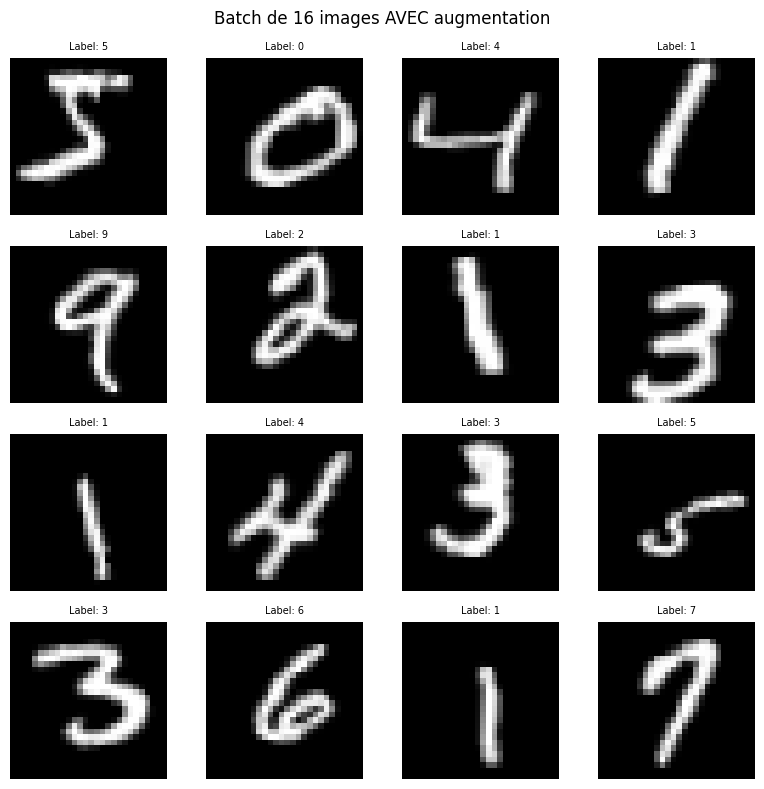

In [ ]:
# 5) DataGenerator AVEC augmentation
gen_aug = ImageDataGenerator(
    rotation_range=10,        # rotation aléatoire entre -10° et +10°
    zoom_range=0.15,          # zoom aléatoire (~ ±15%)
    width_shift_range=0.10,   # translation horizontale aléatoire jusqu'à 10% de la largeur
    height_shift_range=0.10  # translation verticale aléatoire jusqu'à 10% de la hauteur
)

# shuffle=False pour garder un batch stable (mêmes images de base → pour comparaison)
flow_aug = gen_aug.flow(
    x_train_final_norm,
    y_train_final,
    batch_size=batch_size,
    shuffle=False
)

# Récupérer un batch augmenté
X_batch_aug, y_batch_aug = next(flow_aug)

print('Batch augmenté:', X_batch_aug.shape)

# Affichage simple 4×4 (comme avant)
fig, ax = plt.subplots(4, 4, figsize=(8, 8))
for i in range(4):
    for j in range(4):
        ax[i][j].axis('off')
        ax[i][j].imshow(X_batch_aug[i*4 + j].squeeze(), cmap='gray')
        ax[i][j].set_title(f'Label: {int(y_batch_aug[i*4+j])}', fontsize=7)
plt.suptitle('Batch de 16 images AVEC augmentation')
plt.tight_layout()
plt.show()

In [ ]:
# 6) CNN simple + comparaison Sans vs Avec augmentation
def build_simple_cnn():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(16, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')  # 10 classes
    ])
    model.compile(
        optimizer='adam',
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),  # labels entiers
        metrics=['accuracy']
    )
    return model


In [ ]:
epochs = 3  # à augmenter à 5/8 selon le temps d'entraînement

# A) Entraînement SANS augmentation
model_no_aug = build_simple_cnn()
history_no_aug = model_no_aug.fit(
    x_train_final_norm, y_train_final,
    validation_data=(x_val_norm, y_val),
    epochs=epochs,
    batch_size=128,
    verbose=1
)

Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9090 - loss: 0.3109 - val_accuracy: 0.9717 - val_loss: 0.0979
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9750 - loss: 0.0824 - val_accuracy: 0.9788 - val_loss: 0.0727
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9818 - loss: 0.0590 - val_accuracy: 0.9824 - val_loss: 0.0603


In [ ]:
test_loss_no_aug, test_acc_no_aug = model_no_aug.evaluate(x_test_norm, y_test, verbose=0)
print('\n[Sans augmentation] Test accuracy =', test_acc_no_aug)


[Sans augmentation] Test accuracy = 0.9825999736785889


In [ ]:
# B) Entraînement AVEC augmentation
model_aug = build_simple_cnn()

train_flow_aug = gen_aug.flow(x_train_final_norm, y_train_final, batch_size=128, shuffle=True)

steps_per_epoch = int(np.ceil(len(x_train_final_norm) / 128))

history_aug = model_aug.fit(
    train_flow_aug,
    steps_per_epoch=steps_per_epoch,
    validation_data=(x_val_norm, y_val),
    epochs=epochs,
    verbose=1
)

Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.8126 - loss: 0.5999 - val_accuracy: 0.9631 - val_loss: 0.1245
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.9320 - loss: 0.2275 - val_accuracy: 0.9750 - val_loss: 0.0836
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.9471 - loss: 0.1727 - val_accuracy: 0.9760 - val_loss: 0.0779


In [ ]:
test_loss_aug, test_acc_aug = model_aug.evaluate(x_test_norm, y_test, verbose=0)
print('\n[Avec augmentation] Test accuracy =', test_acc_aug)


[Avec augmentation] Test accuracy = 0.9783999919891357


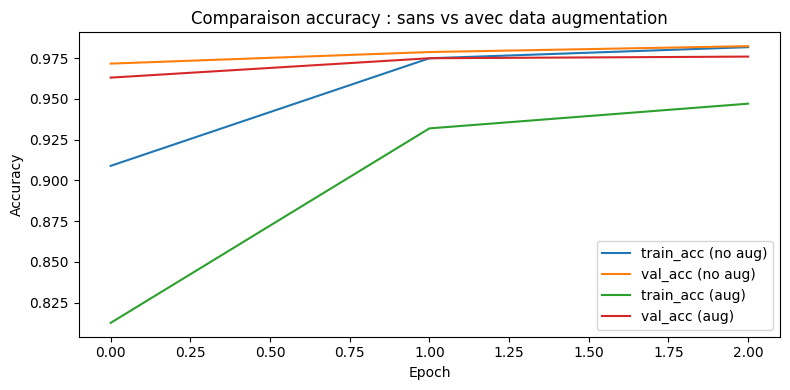

In [ ]:
# 7) Comparaison visuelle des courbes
plt.figure(figsize=(8, 4))
plt.plot(history_no_aug.history['accuracy'],     label='train_acc (no aug)')
plt.plot(history_no_aug.history['val_accuracy'],  label='val_acc (no aug)')
plt.plot(history_aug.history['accuracy'],         label='train_acc (aug)')
plt.plot(history_aug.history['val_accuracy'],     label='val_acc (aug)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Comparaison accuracy : sans vs avec data augmentation')
plt.legend()
plt.tight_layout()
plt.show()